In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob

In [43]:
# Read in the data
dataset = "HCC44-GFP_062023-Stitching-02"
# dataset = "MCAK_micronuclei_062023"
folder = Path(f'../data/{dataset}/predictions/').resolve()

In [44]:
# Initialize list
df_list = []
for s in list(folder.iterdir()):
    if s.name.endswith('summary.csv'):
        df = pd.read_csv(s).rename(columns={"Unnamed: 0": "", "micronuclei":s.name.split("_fv")[0]}).set_index('')
        df_list.append(df)
summary = pd.concat(df_list, axis=1).sort_index().T.sort_index()

In [45]:
subset = summary[["total_cells", "total_micronuclei", "micronuclei_ratio", "cells_with_micronuclei", "cells_with_micronuclei_ratio"]]
subset.to_csv(f'../data/{dataset}/summary.csv')

In [46]:
summary = summary.drop(index=["s22", "s23", "s24"])

KeyError: "['s22', 's23', 's24'] not found in axis"

In [39]:
summary

,0,1,2,3,4,5,6,7,cells_with_micronuclei,cells_with_micronuclei_ratio,micronuclei_ratio,total_cells,total_micronuclei
MCAK_micronuclei_062023_s01_e10_rf0.7_summary.csv,884.0,205.0,48.0,4.0,2.0,NaN,NaN,NaN,259.0,0.226597,0.280840,1143.0,321.0
MCAK_micronuclei_062023_s02_e10_rf0.7_summary.csv,1142.0,267.0,29.0,4.0,2.0,NaN,NaN,NaN,302.0,0.209141,0.238920,1444.0,345.0
MCAK_micronuclei_062023_s03_e10_rf0.7_summary.csv,1323.0,290.0,30.0,4.0,NaN,NaN,NaN,NaN,324.0,0.196721,0.219794,1647.0,362.0
MCAK_micronuclei_062023_s04_e10_rf0.7_summary.csv,1218.0,269.0,30.0,3.0,NaN,NaN,NaN,NaN,302.0,0.198684,0.222368,1520.0,338.0
MCAK_micronuclei_062023_s05_e10_rf0.7_summary.csv,954.0,214.0,29.0,5.0,1.0,1.0,NaN,NaN,250.0,0.207641,0.245847,1204.0,296.0
MCAK_micronuclei_062023_s06_e10_rf0.7_summary.csv,900.0,175.0,21.0,4.0,NaN,1.0,NaN,NaN,201.0,0.182561,0.212534,1101.0,234.0
MCAK_micronuclei_062023_s13_e10_rf0.7_summary.csv,2343.0,465.0,78.0,21.0,3.0,NaN,1.0,NaN,568.0,0.195122,0.241154,2911.0,702.0
MCAK_micronuclei_062023_s14_e10_rf0.7_summary.csv,2494.0,511.0,81.0,15.0,6.0,NaN,NaN,NaN,613.0,0.197296,0.238816,3107.0,742.0
MCAK_micronuclei_062023_s15_e10_rf0.7_summary.csv,2425.0,562.0,81.0,20.0,5.0,4.0,1.0,NaN,673.0,0.217237,0.267915,3098.0,830.0
MCAK_micronuclei_062023_s16_e10_rf0.7_summary.csv,2395.0,546.0,74.0,23.0,6.0,3.0,2.0,1.0,655.0,0.214754,0.269180,3050.0,821.0


In [40]:
# Add column to summary with the sample group
# summary['group'] = ["H441", "H441", "H441", "H441",
#                     "HCC44", "HCC44", "HCC44", "HCC44",
#                     "H441_sg1", "H441_sg1", "H441_sg1", "H441_sg1",
#                     "HCC44_LKB1-WT", "HCC44_LKB1-WT","HCC44_LKB1-WT", "HCC44_LKB1-WT",
#                     "H358", "H358", "H358", "H358",
#
#                     "H358_sg1", "H358_sg1", "H358_sg1", "H358_sg1",
#                     "H2030_LKB1_WT", "H2030_LKB1_WT", "H2030_LKB1_WT", "H2030_LKB1_WT",
#                     "H2030", "H2030", "H2030", "H2030",
#                     "H2030_LKB1_G56W", "H2030_LKB1_G56W", "H2030_LKB1_G56W", "H2030_LKB1_G56W",
#                     "H2030_KIF2C", "H2030_KIF2C", "H2030_KIF2C", "H2030_KIF2C"]

In [47]:
summary["group"] = ["HCC44-GFP", "HCC44-GFP", "HCC44-GFP", "HCC44-GFP"]

In [48]:
# # "MCAK_micronuclei_062023"
# summary["group"] = ["HCC44-MCAK","HCC44-MCAK","HCC44-MCAK","HCC44-MCAK","HCC44-MCAK","HCC44-MCAK",
#                     "H2030-MCAK","H2030-MCAK","H2030-MCAK","H2030-MCAK","H2030-MCAK","H2030-MCAK",
#                      "H2030-GFP","H2030-GFP","H2030-GFP","H2030-GFP","H2030-GFP","H2030-GFP",]

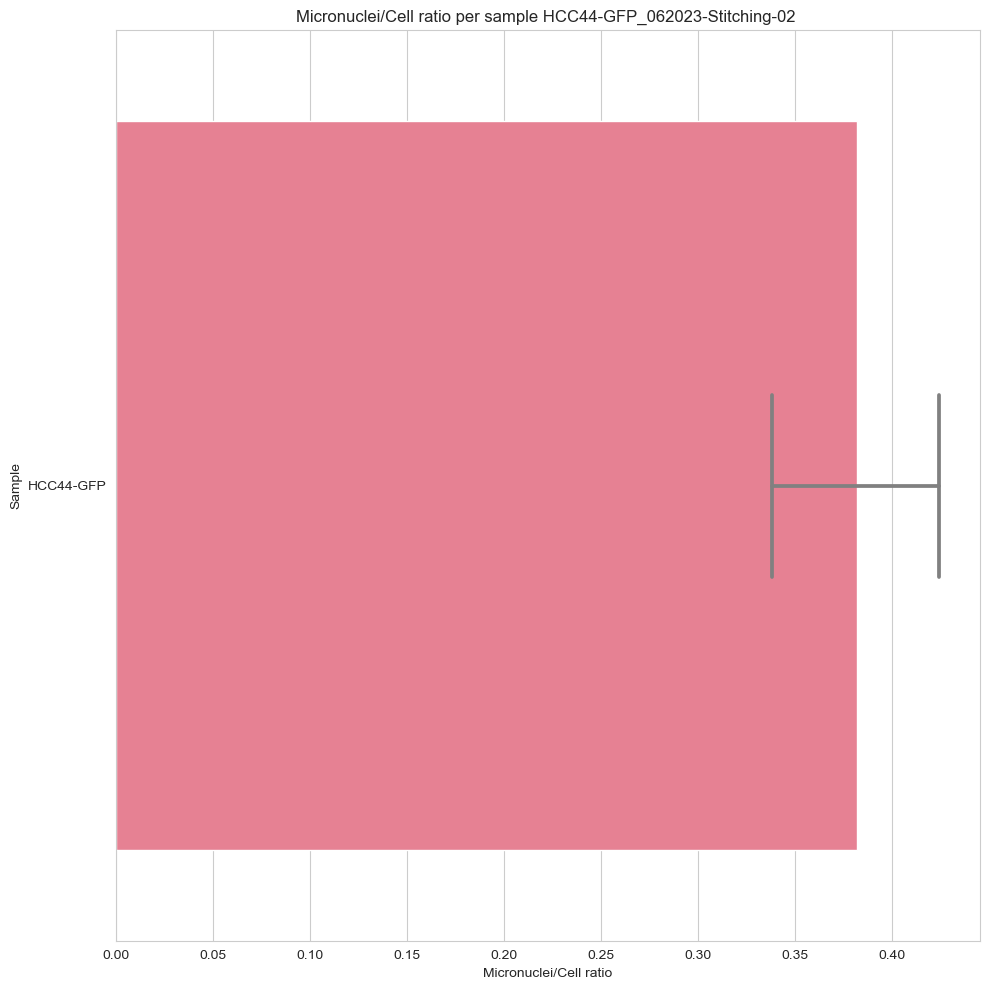

In [49]:
# Initialize figure
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.barplot(data=summary, x='micronuclei_ratio', y=summary.group, ax=ax, palette="husl", errcolor="grey", capsize=0.2)
ax.set_xlabel('Micronuclei/Cell ratio')
ax.set_ylabel('Sample')
ax.set_title(f'Micronuclei/Cell ratio per sample {dataset} ')
plt.tight_layout()
# plt.savefig('../figures/week5.png', dpi=300)